# Classes distribution

In [15]:
from run_easg import EASGData
from dataset import myEASGDataset
from pathlib import Path
with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
train_dataset = myEASGDataset(train_original)
batch_size = 1
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

validation_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
validation_dataset = myEASGDataset(validation_original)

In [44]:
for i,el in enumerate(train_original):
    if el['rels_vecs'][0][1] != 1:
        print(i)

233
546
1162
3480


In [43]:
train_original[0]['rels_vecs']

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [47]:
import torch
labels_verbs = []
labels_rels = []
labels_objs = []
for idx in range(len(train_dataset)):
    labels_verbs.append(train_dataset.get_verb_index(idx).item())
    labels_rels.append(torch.nonzero(train_dataset.get_rels(idx))[:,1])
    labels_objs.append(train_dataset.get_object_indices(idx))

263 1397
21 1116
171 913
96 587
354 179
330 167
33 156
243 134
220 112
84 87
110 78
23 77
67 72
383 65
335 64
118 62
153 61
18 61
240 60
73 60
149 57
301 54
17 53
34 52
207 52
316 51
291 50
251 48
15 47
290 46
388 45
376 45
4 44
43 43
182 43
86 41
380 41
117 39
174 38
50 36
198 36
215 34
312 34
22 33
6 33
46 30
288 30
191 29
317 29
289 27
164 25
357 25
219 24
217 23
52 23
239 22
212 22
270 22
210 22
310 22
359 21
190 21
302 21
284 21
85 20
100 20
139 19
44 19
373 19
211 18
257 18
178 18
246 18
95 17
80 17
40 17
305 17
25 17
208 16
389 15
30 15
278 15
120 14
187 14
143 14
350 14
229 14
98 14
279 14
141 13
62 13
132 13
49 13
304 13
344 12
336 12
159 12
160 12
237 12
379 11
92 11
313 11
130 11
378 11
81 11
214 10
299 10
362 10
368 10
150 10
209 10
298 10
127 10
193 10
51 9
167 8
133 8
285 8
260 8
170 8
294 8
338 7
258 7
307 7
161 7
61 7
109 7
39 7
227 7
93 7
101 6
175 6
64 6
247 6
201 6
348 6
300 6
248 6
297 6
107 6
8 6
148 6
65 5
13 5
370 5
266 5
375 5
194 5
328 5
72 5
79 5
321 5
253 5
2

<Axes: ylabel='Frequency'>

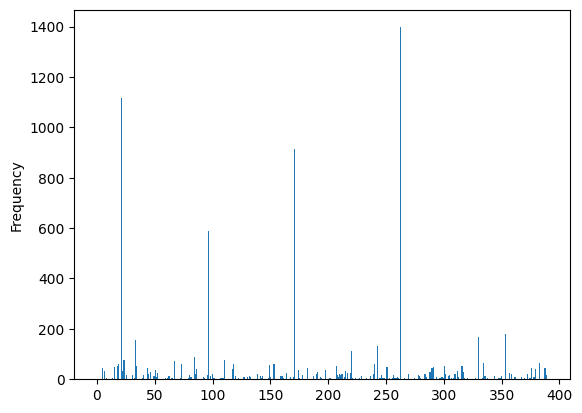

In [68]:
# DISTRIBUTION OBJECTS IN DATASET
labels_objs_bis = []
for el in labels_objs:
    for e in el:
        labels_objs_bis.append(e.item())

import pandas as pd
labels_objs_pd = pd.Series(labels_objs_bis)
pp_objs = labels_objs_pd.value_counts()
for i in pp_objs.index:
    print(i, pp_objs.loc[i])

labels_objs_pd.plot.hist(bins=391)

1 3819
12 3196
3 694
2 342
6 312
5 80
9 31
11 3
0 3
4 2
8 2
10 1


<Axes: ylabel='Frequency'>

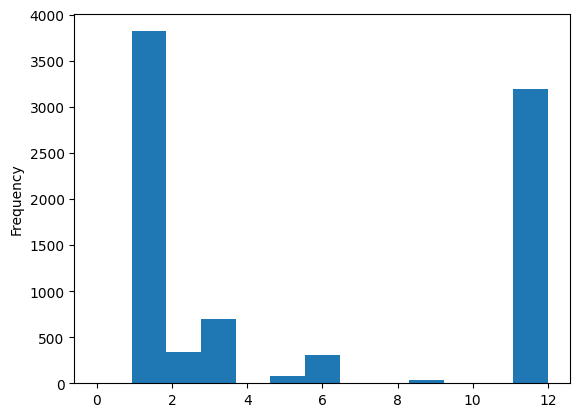

In [69]:
# DISTRIBUTION RELATIONSHIP IN DATASET
labels_rels_bis = []
for el in labels_rels:
    for e in el:
        labels_rels_bis.append(e.item())
labels_rels_bis

import pandas as pd
labels_rels_pd = pd.Series(labels_rels_bis)
pp_rels = labels_rels_pd.value_counts()
for i in pp_rels.index:
    print(i, pp_rels.loc[i])

labels_rels_pd.plot.hist(bins=13)

89 508
36 388
91 308
12 211
108 158
58 156
115 137
1 120
162 115
92 107
79 96
82 81
174 68
98 59
26 54
86 46
103 46
104 42
177 38
102 38
18 34
69 34
21 32
29 32
30 31
193 31
119 31
120 29
178 29
173 28
85 28
49 27
124 25
65 25
181 24
112 23
4 21
164 20
77 17
132 17
60 17
154 15
105 14
109 13
34 12
10 12
13 12
5 11
46 10
122 10
126 10
95 9
57 9
63 9
72 9
127 9
84 9
196 8
128 8
129 8
197 8
83 8
135 8
144 8
133 8
186 7
155 7
87 7
52 7
148 7
48 7
111 6
74 6
24 6
110 6
90 6
43 6
15 6
191 5
41 5
157 5
114 5
101 5
170 4
22 4
66 4
28 4
137 4
76 4
175 4
141 4
134 4
158 3
166 3
33 3
125 3
121 3
160 3
188 3
0 3
171 3
131 3
64 3
25 2
59 2
151 2
11 2
19 2
51 2
16 2
183 2
184 2
8 2
20 2
42 2
194 2
159 2
163 2
62 2
130 2
70 2
150 2
3 2
14 2
195 1
99 1
23 1
152 1
168 1
71 1
31 1
139 1
56 1
32 1
147 1
61 1
161 1
189 1
190 1
39 1
67 1
6 1
176 1
165 1
156 1
80 1
167 1
142 1
100 1
146 1
40 1
187 1
88 1
9 1
143 1
153 1
38 1
149 1


<Axes: ylabel='Frequency'>

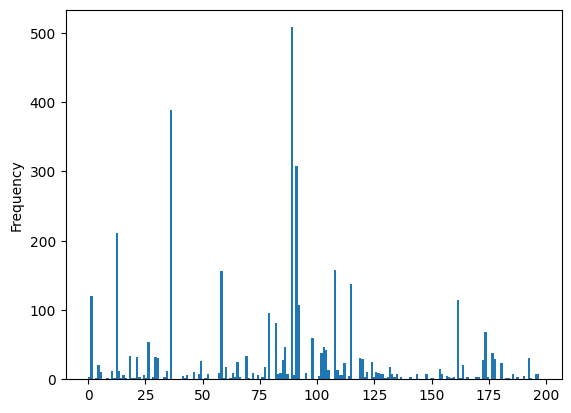

In [70]:
# DISTRIBUTION VERBS IN DATASET
import pandas as pd
labels_verbs_pd = pd.Series(labels_verbs)
pp_verbs = labels_verbs_pd.value_counts()
for i in pp_verbs.index:
    print(i, pp_verbs.loc[i])
labels_verbs_pd.plot.hist(bins=198)

## same thing on validation

In [73]:
import torch
labels_verbs_val = []
labels_rels_val = []
labels_objs_val = []
for idx in range(len(validation_dataset)):
    labels_verbs_val.append(validation_dataset.get_verb_index(idx).item())
    labels_rels_val.append(torch.nonzero(validation_dataset.get_rels(idx))[:,1])
    labels_objs_val.append(validation_dataset.get_object_indices(idx))

263 969
171 564
21 492
330 116
50 104
383 86
380 84
86 81
120 80
49 75
251 72
388 70
67 61
33 61
290 60
217 59
96 58
46 50
194 50
40 46
302 44
291 42
220 42
34 41
153 39
252 38
277 38
219 36
117 36
224 33
345 32
376 32
273 30
292 30
73 29
316 28
370 28
17 27
22 25
175 24
110 23
239 21
98 21
373 20
266 20
100 20
344 20
201 19
109 19
336 18
240 18
18 18
143 18
80 18
15 17
27 17
207 17
313 17
259 16
25 16
4 16
246 16
299 16
149 16
141 15
335 15
160 14
7 14
44 14
284 14
359 13
186 13
329 13
362 13
178 13
166 12
174 12
23 12
265 12
215 12
32 10
11 9
72 9
95 9
170 9
208 9
342 9
180 9
58 8
317 8
89 8
101 8
123 8
162 8
26 8
323 8
132 7
358 7
243 7
311 7
164 7
135 7
210 7
228 7
312 7
322 7
211 6
131 6
10 6
247 6
52 6
225 6
195 6
182 6
45 6
99 5
387 5
155 5
167 5
204 5
295 5
324 5
157 5
385 4
13 4
354 4
338 4
59 4
65 4
379 4
185 4
85 4
318 4
79 4
184 4
8 4
66 4
126 4
258 4
209 4
206 4
356 4
3 4
200 4
76 4
177 4
248 3
118 3
74 3
374 3
276 3
107 3
199 3
113 3
14 3
326 3
229 3
139 3
39 3
84 3
121 3

<Axes: ylabel='Frequency'>

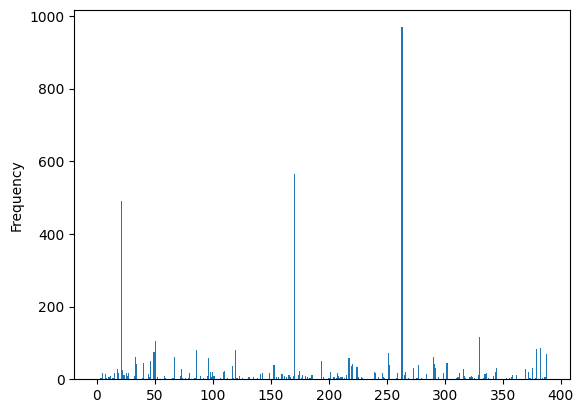

In [75]:
# DISTRIBUTION OBJECTS IN DATASET
labels_objs_bis_val = []
for el in labels_objs_val:
    for e in el:
        labels_objs_bis_val.append(e.item())

import pandas as pd
labels_objs_pd_val = pd.Series(labels_objs_bis_val)
pp_objs_val = labels_objs_pd_val.value_counts()
for i in pp_objs_val.index:
    print(i, pp_objs_val.loc[i])

labels_objs_pd_val.plot.hist(bins=391)

1 2381
12 1810
3 606
2 213
6 198
9 44
5 39
8 3
0 1
10 1
11 1
7 1
4 1


<Axes: ylabel='Frequency'>

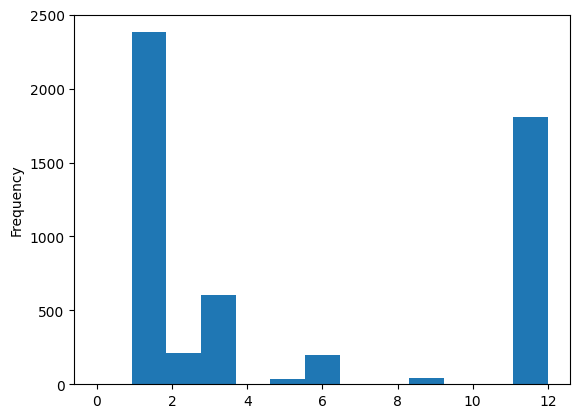

In [76]:
# DISTRIBUTION RELATIONSHIP IN DATASET
labels_rels_bis_val = []
for el in labels_rels_val:
    for e in el:
        labels_rels_bis_val.append(e.item())
labels_rels_bis_val

import pandas as pd
labels_rels_pd_val = pd.Series(labels_rels_bis_val)
pp_rels_val = labels_rels_pd_val.value_counts()
for i in pp_rels_val.index:
    print(i, pp_rels_val.loc[i])

labels_rels_pd_val.plot.hist(bins=13)

89 395
36 199
58 165
91 152
92 114
86 80
115 80
26 79
174 69
108 65
1 57
193 56
103 53
79 51
18 46
162 46
12 38
69 36
82 31
177 26
30 20
40 20
21 19
85 17
104 17
102 16
5 15
95 15
87 13
16 12
196 11
46 11
173 11
49 11
60 10
98 10
52 10
155 10
120 10
164 9
124 9
127 9
75 9
72 8
147 8
186 8
112 7
62 7
48 7
57 7
109 7
130 7
73 6
170 6
10 6
135 6
163 6
34 6
143 6
7 5
166 5
121 5
134 5
151 4
111 4
11 4
169 4
129 4
23 3
117 3
2 3
105 3
145 3
50 3
144 3
65 3
66 3
192 3
94 2
194 2
47 2
172 2
182 2
71 2
110 2
190 2
178 2
191 2
56 2
157 2
24 2
37 2
148 2
154 2
76 2
0 1
156 1
118 1
93 1
138 1
81 1
68 1
74 1
44 1
53 1
179 1
107 1
128 1
136 1
96 1
123 1
45 1
54 1
84 1
33 1
185 1
181 1
78 1
17 1
140 1
27 1
83 1
35 1
4 1
29 1
106 1
180 1
113 1
55 1
20 1
116 1
122 1
97 1


<Axes: ylabel='Frequency'>

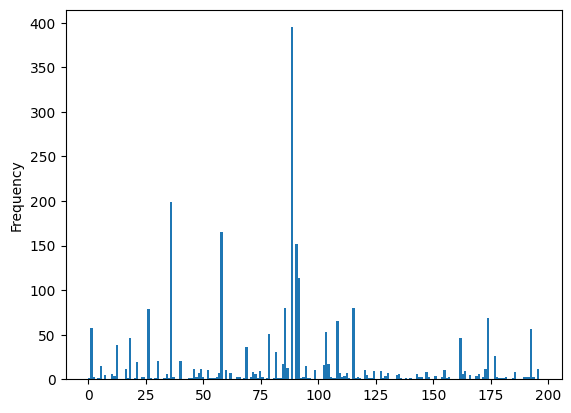

In [77]:
# DISTRIBUTION VERBS IN DATASET
import pandas as pd
labels_verbs_pd_val = pd.Series(labels_verbs_val)
pp_verbs_val = labels_verbs_pd_val.value_counts()
for i in pp_verbs_val.index:
    print(i, pp_verbs_val.loc[i])
labels_verbs_pd_val.plot.hist(bins=198)

# BASELINE: training original paper

In [1]:
from pathlib import Path
annts_path = Path('annts_in_new_format')
out_path = Path('my_output')
data_path = Path('data')

In [8]:
!python run_easg.py annts_in_new_format data my_output --num_epoch=30

04/23/2024 14:58:35.462 Popen(['git', 'rev-parse', '--show-toplevel'], cwd=/home/mscoleri/projects/easg_classification, stdin=None, shell=False, universal_newlines=False)
04/23/2024 14:58:35.465 Popen(['git', 'rev-parse', '--show-toplevel'], cwd=/home/mscoleri/projects/easg_classification, stdin=None, shell=False, universal_newlines=False)
04/23/2024 14:58:35.883 Starting new HTTPS connection (1): api.wandb.ai:443
04/23/2024 14:58:36.139 https://api.wandb.ai:443 "POST /graphql HTTP/1.1" 200 None
04/23/2024 14:58:36.289 https://api.wandb.ai:443 "POST /graphql HTTP/1.1" 200 None
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
04/23/2024 14:58:36.306 Popen(['git', 'cat-file', '--batch-check'], cwd=/home/mscoleri/projects/easg_classification, stdin=<valid stream>, shell=False, universal_newlines=False)
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_14583

# My MLP: Linear Projection + Classificator

In [15]:
# with consine annealing

!python no_gnn_train.py --num_epochs=30

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_153830-hbrrlzmv
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run giddy-moon-4
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_mlp
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_mlp/runs/hbrrlzmv
Epoch 1, Loss: 5.3906, with: [(57.35, 57.35, 57.35), (36.80, 38.80, 48.02), (12.97, 14.48, 16.95)], no: [(87.76, 94.79, 96.88), (47.76, 54.75, 58.62), (14.73, 17.02, 18.85)]
Epoch 6, Loss: 2.0199, with: [(66.13, 66.13, 66.13), (42.05, 44.81, 51.88), (14.12, 15.98, 17.78)], no: [(93.17, 96.51, 96.89), (52.01, 58.12, 61.70), (15.42, 18.02, 19.50)]
Epoch 11, Loss: 0.8454, with: [(58.79, 58.79, 58.79), (40.49, 42.33, 47.53), (12.88, 14.44, 15.81)], no: [(88.34, 96.00, 96.89), (50.94, 56.89, 60.53), (13.60, 16.61, 18.12)]
Epoch 16, Los

In [12]:
# with stepLR

!python no_gnn_train.py --num_epochs=30 --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_220104-050irrof
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dashing-shadow-6
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_mlp
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_mlp/runs/050irrof
Epoch 1, Loss: 5.3952, with: [(60.95, 60.95, 60.95), (40.45, 43.21, 51.28), (13.82, 15.55, 17.42)], no: [(94.36, 96.68, 96.89), (51.60, 58.57, 61.39), (14.96, 17.71, 19.01)]
Epoch 6, Loss: 2.4714, with: [(63.57, 63.57, 63.57), (40.10, 41.96, 48.67), (12.42, 13.92, 15.59)], no: [(93.17, 96.63, 96.89), (50.78, 56.82, 60.26), (13.24, 16.27, 17.75)]
Epoch 11, Loss: 1.5918, with: [(58.89, 58.89, 58.89), (38.69, 40.34, 46.25), (11.57, 13.12, 14.71)], no: [(91.54, 96.65, 96.89), (48.90, 54.25, 58.48), (12.34, 14.86, 16.73)]
Epoch 16,

# Complete model with cosine annealing

In [17]:
# GCN model

!python train.py --num_epochs=30 --graph_type='gcn' --scheduler_type='cosine_annealing'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_155742-jxs9xzlo
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run honest-donkey-2
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gcn
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gcn/runs/jxs9xzlo
Epoch 1, Loss: 8.2623, with: [(44.45, 44.45, 44.45), (1.07, 3.22, 9.17), (0.00, 0.00, 0.65)], no: [(93.17, 96.74, 96.89), (11.91, 29.38, 40.46), (0.00, 5.51, 8.00)]
Epoch 6, Loss: 7.7556, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 10.30), (0.00, 0.32, 0.52)], no: [(93.04, 96.74, 96.89), (11.86, 29.34, 40.29), (2.47, 5.70, 8.86)]
Epoch 11, Loss: 7.7221, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.69), (0.00, 0.00, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epoch 

In [18]:
# SAGE model

!python train.py --num_epochs=30 --graph_type='sage' --scheduler_type='cosine_annealing'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_161249-1kykl8ym
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run elated-cherry-3
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_sage
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_sage/runs/1kykl8ym
Epoch 1, Loss: 14.1191, with: [(44.45, 44.45, 44.45), (1.53, 2.76, 10.01), (0.00, 0.32, 0.68)], no: [(93.17, 96.74, 96.89), (11.91, 30.41, 41.48), (0.00, 5.51, 8.01)]
Epoch 6, Loss: 7.7567, with: [(44.45, 44.45, 44.45), (1.49, 2.72, 9.48), (0.00, 0.00, 0.61)], no: [(93.04, 96.74, 96.89), (14.39, 30.36, 41.31), (0.00, 5.68, 8.84)]
Epoch 11, Loss: 7.7230, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.33), (0.00, 0.00, 0.61)], no: [(93.19, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epo

In [19]:
# GAT model

!python train.py --num_epochs=30 --graph_type='gat' --scheduler_type='cosine_annealing'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_162713-9xt1okhp
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run brisk-serenity-2
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gat
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gat/runs/9xt1okhp


Epoch 1, Loss: 8.2967, with: [(44.45, 44.45, 44.45), (1.07, 2.76, 9.45), (0.32, 0.35, 0.63)], no: [(93.17, 96.74, 96.89), (11.91, 29.38, 40.46), (0.00, 5.51, 8.00)]
Epoch 6, Loss: 7.7576, with: [(44.45, 44.45, 44.45), (1.03, 3.10, 10.00), (0.00, 0.00, 0.52)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.68, 8.86)]
Epoch 11, Loss: 7.7227, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.33), (0.00, 0.00, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epoch 16, Loss: 7.7546, with: [(44.45, 44.45, 44.45), (1.49, 2.72, 9.79), (0.00, 0.00, 0.66)], no: [(93.17, 96.74, 96.89), (14.39, 30.36, 41.44), (0.00, 5.51, 8.00)]
Epoch 21, Loss: 7.7791, with: [(44.45, 44.45, 44.45), (1.49, 2.04, 9.31), (0.00, 0.35, 0.64)], no: [(93.04, 96.74, 96.89), (1.49, 30.36, 41.31), (0.00, 2.28, 3.53)]
Epoch 26, Loss: 7.7554, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 11.10), (0.00, 0.00, 0.58)], no: [(93.04, 96.74, 96.89), (14.39, 29.34, 40.29), (2.47, 5.53, 8.00)]
Model

# Complete model with stepLR

In [5]:
# GCN

!python train.py --num_epochs=30 --graph_type='gcn' --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_210745-k19i5u8d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run splendid-lion-7
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gcn
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gcn/runs/k19i5u8d
Epoch 1, Loss: 8.5609, with: [(44.45, 44.45, 44.45), (1.53, 2.76, 9.32), (0.00, 0.32, 0.65)], no: [(93.17, 96.74, 96.89), (14.43, 30.30, 41.48), (0.00, 5.68, 8.84)]
Epoch 6, Loss: 7.7827, with: [(44.45, 44.45, 44.45), (1.49, 2.72, 10.87), (0.00, 0.00, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 30.36, 41.44), (0.00, 5.68, 8.86)]
Epoch 11, Loss: 7.7592, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.17), (0.00, 0.32, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epoch 

In [10]:
# SAGE

!python train.py --num_epochs=30 --graph_type='sage' --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_212928-582tvrpn
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run peachy-firebrand-6
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_sage
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_sage/runs/582tvrpn
Epoch 1, Loss: 8.3848, with: [(44.45, 44.45, 44.45), (1.07, 3.08, 9.01), (0.00, 0.00, 0.65)], no: [(93.17, 96.74, 96.89), (14.43, 29.38, 40.47), (2.82, 5.53, 8.00)]
Epoch 6, Loss: 7.7813, with: [(44.45, 44.45, 44.45), (1.03, 2.93, 10.99), (0.00, 0.32, 0.55)], no: [(93.17, 96.74, 96.89), (19.36, 29.34, 40.42), (2.82, 5.70, 8.86)]
Epoch 11, Loss: 7.7577, with: [(44.45, 44.45, 44.45), (1.49, 2.72, 10.12), (0.00, 0.32, 0.63)], no: [(93.04, 96.74, 96.89), (11.86, 30.36, 41.31), (0.00, 5.51, 8.00)]


In [11]:
# GAT

!python train.py --num_epochs=30 --graph_type='gat' --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_214351-kmonmwtf
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lucky-frost-5
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gat
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gat/runs/kmonmwtf
Epoch 1, Loss: 9.6209, with: [(44.45, 44.45, 44.45), (1.07, 3.52, 10.58), (0.00, 0.00, 0.56)], no: [(93.04, 96.74, 96.89), (14.39, 29.28, 40.46), (0.00, 5.68, 8.84)]
Epoch 6, Loss: 7.8013, with: [(44.45, 44.45, 44.45), (1.12, 2.72, 8.94), (0.00, 0.32, 0.58)], no: [(93.17, 96.74, 96.89), (11.86, 29.43, 40.50), (0.00, 5.51, 8.01)]
Epoch 11, Loss: 7.7573, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.35), (0.00, 0.00, 0.55)], no: [(93.04, 96.74, 96.89), (11.86, 29.34, 40.29), (0.00, 5.68, 8.84)]
Epoch 16

In [2]:
!python train.py --num_epochs=30 --graph_type='gcn' --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --scheduler_type='step' --no-wandb

Epoch 1, Loss: 8.5861, with: [(44.45, 44.45, 44.45), (1.16, 2.69, 9.54), (0.00, 0.32, 0.63)], no: [(93.17, 96.72, 96.89), (11.91, 29.47, 40.54), (0.00, 5.51, 8.01)]
Epoch 6, Loss: 7.7810, with: [(44.45, 44.45, 44.45), (1.03, 2.65, 10.55), (0.00, 0.35, 0.61)], no: [(93.19, 96.74, 96.89), (1.03, 29.24, 40.42), (0.00, 5.47, 8.01)]
Epoch 11, Loss: 7.7590, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.01), (0.00, 0.32, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]


# Complete model with stepLR and changing dimensions:
--proj_dim=1024 --hidden_dim=512 --output_dim=256 --scheduler_type='step'

In [13]:
!python train.py --num_epochs=30 --graph_type='gcn' --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_221327-pqqbhqjb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run whole-field-8
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gcn
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gcn/runs/pqqbhqjb
Epoch 1, Loss: 11.8602, with: [(44.45, 44.45, 44.45), (1.16, 2.76, 10.19), (0.00, 0.32, 0.56)], no: [(93.17, 96.74, 96.89), (11.91, 29.47, 40.55), (0.00, 5.89, 8.22)]
Epoch 6, Loss: 7.7805, with: [(44.45, 44.45, 44.45), (1.03, 3.10, 10.77), (0.00, 0.00, 0.58)], no: [(93.04, 96.74, 96.89), (17.77, 29.34, 40.43), (0.88, 1.91, 2.73)]
Epoch 11, Loss: 7.8533, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.63), (0.00, 0.32, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epoch 

In [14]:
!python train.py --num_epochs=30 --graph_type='sage' --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_222844-bv5bopan
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run royal-shape-7
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_sage
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_sage/runs/bv5bopan
Epoch 1, Loss: 8.3774, with: [(44.45, 44.45, 44.45), (1.53, 2.76, 9.20), (0.00, 0.00, 0.65)], no: [(93.23, 96.74, 96.89), (14.39, 30.41, 41.49), (1.62, 5.69, 8.82)]
Epoch 6, Loss: 7.7825, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 12.24), (0.00, 0.32, 0.58)], no: [(93.04, 96.74, 96.89), (14.39, 29.34, 40.29), (2.47, 5.53, 8.00)]
Epoch 11, Loss: 7.7574, with: [(44.45, 44.45, 44.45), (1.03, 2.72, 9.45), (0.00, 0.35, 0.58)], no: [(93.04, 96.74, 96.89), (11.86, 29.34, 40.29), (0.00, 5.51, 8.00)]
Epoch 

In [15]:
!python train.py --num_epochs=30 --graph_type='gat' --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --scheduler_type='step'

wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.16.6
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240423_224322-ws7rrt65
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run copper-cloud-6
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/easg_classification_gat
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/easg_classification_gat/runs/ws7rrt65
Epoch 1, Loss: 10.4617, with: [(44.45, 44.45, 44.45), (1.07, 2.81, 8.72), (0.00, 0.00, 0.59)], no: [(93.19, 96.72, 96.89), (14.39, 29.38, 40.46), (0.00, 5.89, 8.22)]
Epoch 6, Loss: 7.7987, with: [(44.45, 44.45, 44.45), (1.03, 2.65, 9.56), (0.00, 0.32, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.34, 40.42), (0.00, 5.51, 8.00)]
Epoch 11, Loss: 7.7866, with: [(44.45, 44.45, 44.45), (1.12, 2.93, 10.48), (0.00, 0.35, 0.61)], no: [(93.17, 96.74, 96.89), (11.86, 29.43, 40.50), (2.82, 5.70, 8.84)]
Epoch 

# Prova only_verb

In [ ]:
!python only_verb_train.py --lr_start=0.0005 --num_epochs=1 --graph_type='gcn' --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --no-wandb

In [8]:
!python only_verb_eval.py 'only_verb30_gcn_mean_pd=1024_hd=512_outd=256.pth' --graph_type='gcn' --proj_dim=1024 --hidden_dim=512 --output_dim=256

accuracy: 0.11209068010075567
{'precision': 0.25978246083067974, 'recall': 0.11209068010075567, 'f1-score': 0.09089157824391264, 'support': 2382.0}
{'precision': 0.6527897788496172, 'recall': 0.06967909906058496, 'f1-score': 0.02073288084562046, 'support': 2382.0}


# Prove

In [72]:
!python train.py --num_epochs=1 --graph_type='gcn' --lr_start=0.0005 --scheduler_type='step' --proj_dim=1024 --hidden_dim=512 --output_dim=256 --no-wandb

Epoch 1, Loss: 8.2871
Figure(640x480)
Model saved!
After 1 epochs -> with: [(44.45, 44.45, 44.45), (1.07, 3.15, 9.50), (0.00, 0.32, 0.56)], no: [(93.04, 96.74, 96.89), (14.39, 29.38, 40.33), (0.00, 5.68, 8.84)]


In [6]:
!python eval.py 'trained_models/easg_classifier1_gcn_mean_pd=1024_hd=512_outd=256.pth' --edge_criterion='max' --proj_dim=1024 --hidden_dim=512 --output_dim=256

with: [(44.45, 44.45, 44.45), (1.07, 3.52, 10.83), (0.00, 0.35, 0.65)], no: [(93.17, 96.74, 96.89), (14.57, 29.38, 40.46), (2.84, 5.53, 8.01)]


In [54]:
!wandb offline   

W&B offline. Running your script from this directory will only write metadata locally. Use wandb disabled to completely turn off W&B.
